# Neutron Slowing Down

Recall that, in the absence of absorption and sources, the neutron flux spectrum is governed by 

$$
  \Sigma_s(E) \phi(E) = \int p(E'\to E) \Sigma_s(E')\phi(E') dE' \, .
  \tag{FNRP 3.21}
$$

For elastic scattering governed by the familiar $P(E'\to E) = 1/[(1-\alpha)E']$, $\alpha E' \leq E \leq E'$, the resulting flux spectrum is 

$$
  \phi(E) = \frac{C}{\Sigma_s(E) E} \, .
  \tag{FNRP 3.23}
$$

Often, $\Sigma_s(E)$ is nearly constant, in which case $\boxed{\phi(E) = \frac{C}{E}}$, the well-known "1-over-$E$" spectrum.


The assumptions made limit this approximate spectrum to energies $1 \leq E \leq 10^{5}$ eV or so.  At higher energies, elastic scattering becomes anisotropic, inelastic scattering becomes important, and fission neutrons can contribute directly to the spectrum.  At lower energies, thermal motion of target nuclei can lead to "upscattering," which corresponds to a very different form for $p(E'\to E)$ and the associated spectrum.

**Objective**: In this tutorial, we'll determine how well the 1-over-$E$ approximation holds over the range of interest for a variety of materials. In particular, we will model a monoenergetic (1-MeV) neutron source at the origin of an infinite, homogeneous block of moderating material and estimate the flux between 1 eV and 0.1 MeV using several energy bins.

As always, let's import the relevant modules:

In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt

## Modeling in OpenMC

The basic workflow for creating and usings models in OpenMC consists of these steps:

  1. Define materials
  2. Define a geometry (e.g., surfaces, regions, and cells)
  3. Define simulation settings (e.g., a neutron source or the number of particles to simulate)
  4. Define tallies (e.g., a flux spectrum or fission rate in a cell)
  5. Run OpenMC
  6. Do any postprocessing (e.g., load and plot a tally)

We'll start by creating an OpenMC model:

In [2]:
model = openmc.Model()

## Step 1: Materials

First, let's create a new material to represent light water:

In [3]:
water = openmc.Material(name="h2o")
water.add_nuclide("H1", 2.0)
water.add_nuclide("O16", 1.0)
water.set_density("g/cm3", 1.0)

We can also create a material for graphite:

In [4]:
graphite = openmc.Material(name="graphite")
graphite.add_element("C", 1.0)
graphite.set_density("g/cm3", 2.26)

Then, we add the materials to the model:

In [5]:
model.materials = openmc.Materials([water, graphite])

## Step 2: Geometry

It is not generally feasible to model an infinite domain explicitly.  Rather, we can model a finite region of space with an outer, **reflective** surface.  Here, the simplest way to do that is to create a sphere centered at the origin that is filled with our moderating material.  First, define the sphere:  

In [6]:
sphere = openmc.Sphere(r=1.0, boundary_type="reflective") 

The radius selected is arbitrary since the reflective boundary effectively makes this an infinite domain.

Next, we define a cell whose region of space is everything inside the sphere (`-sphere`) and whose fill material is water:

In [7]:
moderator_cell = openmc.Cell()
moderator_cell.region = -sphere
moderator_cell.fill = water # or graphite


Finally, all of the cells of a model must live inside a universe, and there must be at least one "root" universe in each geometry.  Here, we only need the root universe and assign the cell to it as follows:

In [8]:
root_universe = openmc.Universe(cells=(moderator_cell,))
model.geometry.root_universe = root_universe

## Step 3: Settings

In [9]:
settings = openmc.Settings()
space_distn = openmc.stats.Point((0, 0, 0))
energy_distn = openmc.stats.Discrete([1e6], [1.0])
source = openmc.IndependentSource(space=space_distn, energy=energy_distn)
settings.source = source
settings.batches = 100
settings.particles = 1000
settings.run_mode = "fixed source"
settings.cutoff = {"energy_neutron": 1.0}
model.settings = settings

## Step 4: Tallies

In [10]:
energies = np.logspace(np.log10(1.0), np.log10(0.1e6), 1000)
e_filter = openmc.EnergyFilter(energies)
spectrum_tally = openmc.Tally(name="spectrum")
spectrum_tally.filters = [e_filter]
spectrum_tally.scores = ['flux']
collision_tally = openmc.Tally(name="collision")
collision_tally.scores = ["elastic"]
collision_tally.estimator = "analog"
model.tallies = [spectrum_tally, collision_tally]

## Step 5: Run OpenMC

In [11]:
sp_path = model.run(output=False)

## Step 6: Postprocess Results

In [12]:
with openmc.StatePoint(sp_path) as sp:
    t = sp.tallies[spectrum_tally.id]
    flux_mean = t.mean.ravel()*100*1000*(4/3*np.pi)
    flux_unc = t.std_dev.ravel()*100*1000*(4/3*np.pi)
    t = sp.tallies[collision_tally.id]
    coll_mean = t.mean.ravel()
    coll_unc = t.std_dev.ravel()

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_91844/1915235336.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi(E)$ [n/cm$^2$-s-eV]');


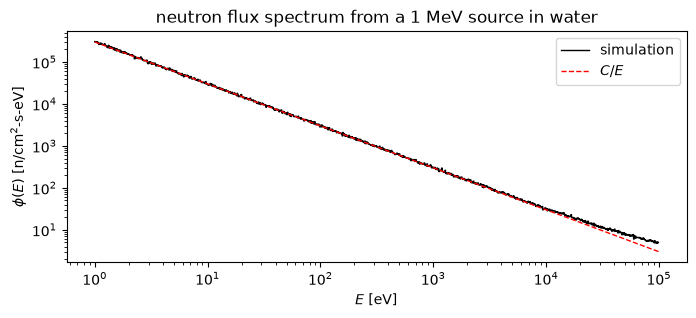

In [13]:
plt.figure(figsize=(8,3))
plt.step(energies[:-1], 
         flux_mean/np.diff(energies), # divide by energy bin for 1/eV
         where='post', color='k', lw=1, label="simulation")
plt.plot(energies[:-1], 3e5/energies[:-1], 'r--', lw=1, label="$C/E$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E$ [eV]')
plt.ylabel('$\phi(E)$ [n/cm$^2$-s-eV]');
plt.legend()
plt.title("neutron flux spectrum from a 1 MeV source in water");

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_91844/4084871185.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi(u) = E\phi(E)$ [n/cm$^2$-s]');


Text(0.5, 1.0, 'neutron flux per unit lethargy')

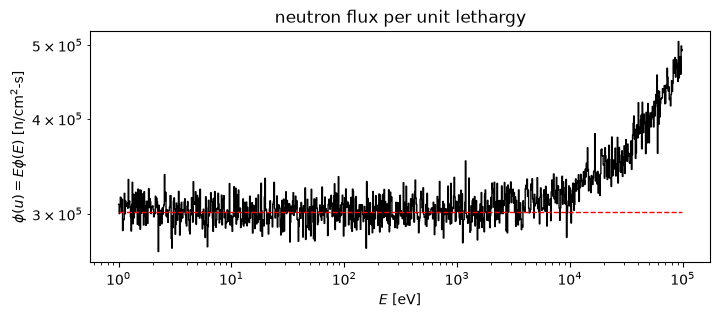

In [14]:
plt.figure(figsize=(8,3))
E_center = (energies[:-1]+energies[1:])/2
plt.step(energies[:-1], 
         E_center*flux_mean/np.diff(energies), 
         where='post', color='k', lw=1, label="simulation")
plt.plot(energies[:-1], E_center*3e5/energies[:-1], 'r--', lw=1, label="$C/E$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E$ [eV]')
plt.ylabel('$\phi(u) = E\phi(E)$ [n/cm$^2$-s]');
plt.title("neutron flux per unit lethargy")

Both of these figures indicate that the spectrum is well approximated by the $1/E$ shape up until about 10 keV, where the simulated flux is larger.  If we apply the more complete spectrum approximation of FNRP Eq. (3.23), an even closer match can be found.

In [15]:
import os
xs_path = os.environ.get("OPENMC_CROSS_SECTIONS").replace("cross_sections.xml", "neutron/")
H1 = openmc.data.IncidentNeutron.from_hdf5(xs_path+"H1.h5")
O16 = openmc.data.IncidentNeutron.from_hdf5(xs_path+"O16.h5")

In [16]:
sigma_e_H1 = H1.reactions[2].xs["294K"]
sigma_e_O16 = O16.reactions[2].xs["294K"]

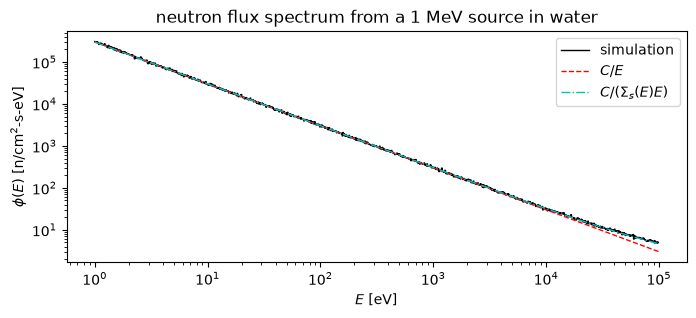

In [17]:
one_over_E = 3e5/energies[:-1]
one_over_E_SigmaS = 1.35e7/((2*sigma_e_H1(energies[:-1])+sigma_e_O16(energies[:-1]))*energies[:-1])

plt.figure(figsize=(8,3))
plt.step(energies[:-1], 
         flux_mean/np.diff(energies), 
         where='post', color='k', lw=1, label="simulation")
plt.plot(energies[:-1], one_over_E, 'r--', lw=1, label=r"$C/E$")
plt.plot(energies[:-1], one_over_E_SigmaS, 'c-.', lw=1, label=r"$C/(\Sigma_s(E)E)$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$E$ [eV]')
plt.ylabel(r'$\phi(E)$ [n/cm$^2$-s-eV]');
plt.legend()
plt.title("neutron flux spectrum from a 1 MeV source in water");

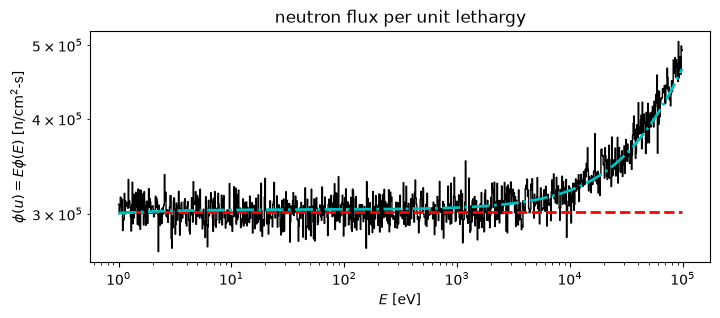

In [18]:
plt.figure(figsize=(8,3))
E_center = (energies[:-1]+energies[1:])/2
plt.step(energies[:-1], 
         E_center*flux_mean/np.diff(energies), 
         where='post', color='k', lw=1, label="simulation")
plt.plot(energies[:-1], E_center*one_over_E, 'r--', lw=2, label="$C/E$")
plt.plot(energies[:-1], E_center*one_over_E_SigmaS, 'c-.', lw=2, label="$C/E$")

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E$ [eV]')
plt.ylabel(r'$\phi(u) = E\phi(E)$ [n/cm$^2$-s]');
plt.title("neutron flux per unit lethargy");

Finally, the mean number of collision per particle and its standard error are as follows:

In [19]:
print(f"{coll_mean} +/ {coll_unc} collisions/particle")

[16.88333] +/ [0.01409373] collisions/particle
